# GNN snapshot audit

This notebook audits the quarterly manager-stock graph inputs created by `scripts/20_build_gnn_snapshots.py`.

The audit examines:

1. graph coverage and agreement with the frozen modeling sample;
2. ownership-edge weights;
3. stock- and manager-feature availability; and
4. node continuity through time.

It reads saved graph inputs only. It does not rebuild snapshots, inspect target outcomes, or make modeling decisions.

## 1. Setup and graph inputs

In [1]:
from pathlib import Path
import sys

import duckdb
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import pandas as pd

project_root = Path.cwd().resolve()
while not (project_root / "config" / "paths.yaml").is_file():
    if project_root.parent == project_root:
        raise RuntimeError("Could not locate the project root.")
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.utils.configuration import get_paths_config
from src.visualization.style import (
    COLOR_PALETTE,
    apply_matplotlib_layout,
    set_matplotlib_style,
)

set_matplotlib_style()
paths = get_paths_config()
modeling_directory = paths.processed / "modeling"
graph_directory = modeling_directory / "gnn"
sample_path = modeling_directory / "modeling_sample.parquet"
stock_path = graph_directory / "stock_nodes.parquet"
manager_path = graph_directory / "manager_nodes.parquet"
edge_path = graph_directory / "ownership_edges.parquet"
audit_path = graph_directory / "snapshot_audit.parquet"

for path in [sample_path, stock_path, manager_path, edge_path, audit_path]:
    if not path.is_file():
        raise FileNotFoundError(f"GNN input not found: {path}")

modeling_sample = pd.read_parquet(
    sample_path,
    columns=["report_period", "information_date", "permno", "sample_split"],
)
audit = pd.read_parquet(audit_path).sort_values("report_period")
stocks = pd.read_parquet(stock_path)
managers = pd.read_parquet(manager_path)

print(f"Snapshots: {len(audit):,}")
print(f"Stock nodes: {len(stocks):,}")
print(f"Manager nodes: {len(managers):,}")
print(f"Ownership edges: {audit['ownership_edges'].sum():,}")
print(f"Coverage: {audit['report_period'].min().date()} to {audit['report_period'].max().date()}")

Snapshots: 51
Stock nodes: 203,069
Manager nodes: 243,563
Ownership edges: 39,190,994
Coverage: 2013-06-30 to 2025-12-31


## 2. Snapshot coverage

All stocks in each modeled quarterly ownership graph are retained. The labeled subset is the previously frozen modeling sample on which loss and evaluation metrics will be computed.

,graph_split,snapshots,stock_nodes,labeled_stocks,manager_nodes,ownership_edges,labeled_stock_share
0,train,34,131465,123791,133762,22498090,94.16%
1,purged,2,8726,0,12023,1825777,0.00%
2,validation,7,31216,29716,42036,6219245,95.19%
3,test,8,31662,30511,55742,8647882,96.36%


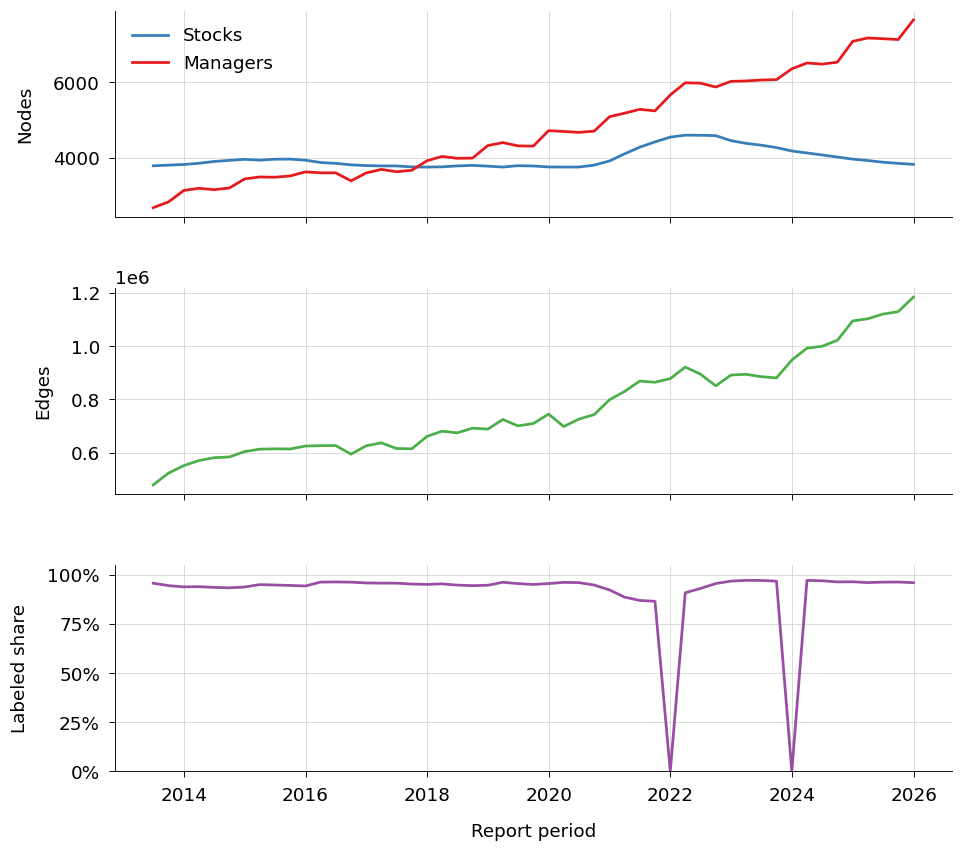

In [2]:
split_summary = (
    audit.groupby("graph_split", sort=False)
    .agg(
        snapshots=("report_period", "size"),
        stock_nodes=("stock_nodes", "sum"),
        labeled_stocks=("labeled_stocks", "sum"),
        manager_nodes=("manager_nodes", "sum"),
        ownership_edges=("ownership_edges", "sum"),
    )
    .reset_index()
)
split_summary["labeled_stock_share"] = split_summary["labeled_stocks"] / split_summary["stock_nodes"]
display(split_summary.style.format({"labeled_stock_share": "{:.2%}"}))

fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
axes[0].plot(audit["report_period"], audit["stock_nodes"], label="Stocks")
axes[0].plot(audit["report_period"], audit["manager_nodes"], label="Managers")
axes[0].set_ylabel("Nodes")
axes[0].legend()
axes[1].plot(audit["report_period"], audit["ownership_edges"], color=COLOR_PALETTE[2])
axes[1].set_ylabel("Edges")
axes[2].plot(
    audit["report_period"],
    audit["labeled_stocks"] / audit["stock_nodes"],
    color=COLOR_PALETTE[3],
)
axes[2].set_ylabel("Labeled share")
axes[2].set_xlabel("Report period")
axes[2].set_ylim(0, 1.05)
axes[2].yaxis.set_major_formatter(PercentFormatter(1))
apply_matplotlib_layout(fig)
fig.savefig(paths.figures / "04_05_snapshot_coverage.pdf")
plt.show()

## 3. Edge-weight audit

`portfolio_weight` measures the importance of a stock within a manager's reported portfolio. `reported_ownership_share` measures the manager's share of the stock's total reported institutional position. Both should be positive and sum to one for the relevant destination node.

In [3]:
connection = duckdb.connect()
try:
    weight_summary = connection.execute(
        """
        SELECT
            COUNT(*) AS edges,
            MIN(portfolio_weight) AS minimum_portfolio_weight,
            MEDIAN(portfolio_weight) AS median_portfolio_weight,
            QUANTILE_CONT(portfolio_weight, 0.99) AS p99_portfolio_weight,
            MAX(portfolio_weight) AS maximum_portfolio_weight,
            MIN(reported_ownership_share) AS minimum_ownership_share,
            MEDIAN(reported_ownership_share) AS median_ownership_share,
            QUANTILE_CONT(reported_ownership_share, 0.99) AS p99_ownership_share,
            MAX(reported_ownership_share) AS maximum_ownership_share
        FROM read_parquet(?)
        """,
        [str(edge_path)],
    ).fetch_df()
    manager_sum_deviation = connection.execute(
        """
        SELECT MAX(ABS(total_weight - 1))
        FROM (
            SELECT report_period, manager_index, SUM(portfolio_weight) AS total_weight
            FROM read_parquet(?)
            GROUP BY report_period, manager_index
        )
        """,
        [str(edge_path)],
    ).fetchone()[0]
    stock_sum_deviation = connection.execute(
        """
        SELECT MAX(ABS(total_share - 1))
        FROM (
            SELECT report_period, security_index, SUM(reported_ownership_share) AS total_share
            FROM read_parquet(?)
            GROUP BY report_period, security_index
        )
        """,
        [str(edge_path)],
    ).fetchone()[0]
finally:
    connection.close()

display(weight_summary.style.format({column: "{:.6f}" for column in weight_summary.columns if column != "edges"}))
print(f"Maximum manager-weight sum deviation: {manager_sum_deviation:.2e}")
print(f"Maximum stock-share sum deviation: {stock_sum_deviation:.2e}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,edges,minimum_portfolio_weight,median_portfolio_weight,p99_portfolio_weight,maximum_portfolio_weight,minimum_ownership_share,median_ownership_share,p99_ownership_share,maximum_ownership_share
0,39190994,0.000000,0.000549,0.080442,1.000000,0.000000,0.000097,0.104915,1.000000


Maximum manager-weight sum deviation: 4.84e-08
Maximum stock-share sum deviation: 4.94e-08


## 4. Node-feature availability

Missingness is shown for labeled observations only. The four change features are expected to be missing when a stock has no immediately preceding quarterly observation; the model will impute them using training-sample medians.

In [4]:
excluded_columns = {
    "report_period", "information_date", "security_index", "permno",
    "target_window_end", "future_max_drawdown_63d", "sample_split",
}
stock_features = [column for column in stocks.columns if column not in excluded_columns]
labeled_stocks = stocks.loc[stocks["sample_split"].notna()]
stock_missingness = (
    labeled_stocks[stock_features].isna().mean().sort_values(ascending=False).rename("missing_share").to_frame()
)
manager_features = [
    "portfolio_value_usd", "security_count", "largest_position_weight", "portfolio_hhi"
]
manager_missingness = managers[manager_features].isna().mean().rename("missing_share").to_frame()

print("Stock features with missing values")
display(stock_missingness.loc[stock_missingness["missing_share"] > 0].style.format("{:.2%}"))
print("Manager-feature missingness")
display(manager_missingness.style.format("{:.2%}"))

Stock features with missing values


,missing_share
reported_ownership_hhi_change,2.08%
institutional_holder_count_change_percent,2.08%
total_reported_value_change_percent,2.08%


Manager-feature missingness


,missing_share
portfolio_value_usd,0.00%
security_count,0.00%
largest_position_weight,0.00%
portfolio_hhi,0.00%


## 5. Quarter-to-quarter node continuity

A temporal model requires persistent node identities. Retention is the share of current-quarter nodes that were also present in the preceding quarter. Purged quarters remain in the graph sequence without labels, allowing the recurrent state to advance while preserving the leakage barrier.

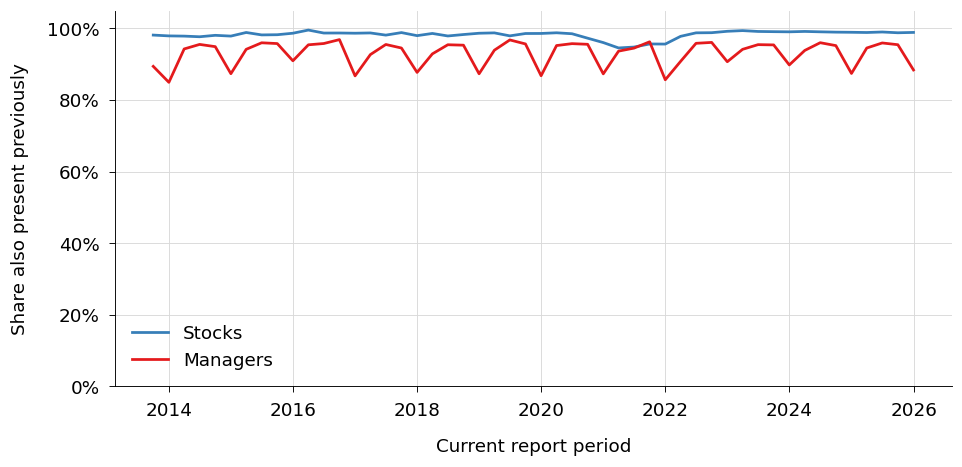

In [5]:
periods = audit["report_period"].sort_values().tolist()
stock_sets = {period: set(group["permno"]) for period, group in stocks.groupby("report_period")}
manager_sets = {period: set(group["CIK"]) for period, group in managers.groupby("report_period")}
continuity_rows = []
for previous, current in zip(periods, periods[1:]):
    quarter_gap = current.to_period("Q").ordinal - previous.to_period("Q").ordinal
    continuity_rows.append(
        {
            "report_period": current,
            "quarter_gap": quarter_gap,
            "stock_retention": len(stock_sets[current] & stock_sets[previous]) / len(stock_sets[current]),
            "manager_retention": len(manager_sets[current] & manager_sets[previous]) / len(manager_sets[current]),
        }
    )
continuity = pd.DataFrame(continuity_rows)

display(continuity.groupby("quarter_gap")[["stock_retention", "manager_retention"]].agg(["count", "mean", "min"]).style.format("{:.2%}"))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(continuity["report_period"], continuity["stock_retention"], label="Stocks")
ax.plot(continuity["report_period"], continuity["manager_retention"], label="Managers")
ax.set_xlabel("Current report period")
ax.set_ylabel("Share also present previously")
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.legend()
apply_matplotlib_layout(fig)
fig.savefig(paths.figures / "04_05_node_retention.pdf")
plt.show()

## 6. Audit conclusion

The final checks verify exact label agreement with the frozen modeling sample, internal table consistency, normalized edge weights, and expected feature missingness.

In [6]:
node_keys = ["report_period", "information_date", "permno"]
sample_labels = modeling_sample[node_keys + ["sample_split"]]
snapshot_labels = labeled_stocks[node_keys + ["sample_split"]]
label_check = sample_labels.merge(
    snapshot_labels,
    on=node_keys,
    how="outer",
    suffixes=("_sample", "_snapshot"),
    indicator=True,
    validate="one_to_one",
)

if not label_check["_merge"].eq("both").all():
    raise RuntimeError("GNN labels do not match the frozen modeling-sample rows.")
if not label_check["sample_split_sample"].eq(label_check["sample_split_snapshot"]).all():
    raise RuntimeError("GNN sample splits do not match the frozen modeling sample.")
if audit["stock_nodes"].sum() != len(stocks):
    raise RuntimeError("Snapshot-audit stock counts do not match the stock-node table.")
if audit["manager_nodes"].sum() != len(managers):
    raise RuntimeError("Snapshot-audit manager counts do not match the manager-node table.")
if audit["ownership_edges"].sum() != weight_summary.loc[0, "edges"]:
    raise RuntimeError("Snapshot-audit edge counts do not match the edge table.")
if audit["report_period"].duplicated().any():
    raise RuntimeError("The snapshot audit contains duplicate report periods.")
if stocks.duplicated(["report_period", "security_index"]).any():
    raise RuntimeError("The stock-node table contains duplicate node keys.")
if managers.duplicated(["report_period", "manager_index"]).any():
    raise RuntimeError("The manager-node table contains duplicate node keys.")
if manager_sum_deviation > 1e-5 or stock_sum_deviation > 1e-5:
    raise RuntimeError("Edge weights do not sum to one within tolerance.")
if weight_summary.loc[0, "minimum_portfolio_weight"] <= 0:
    raise RuntimeError("Portfolio weights must be positive.")
if weight_summary.loc[0, "minimum_ownership_share"] <= 0:
    raise RuntimeError("Reported ownership shares must be positive.")
if manager_missingness["missing_share"].gt(0).any():
    raise RuntimeError("Manager features contain missing values.")

expected_missing_stock_features = {
    "institutional_holder_count_change_percent",
    "total_reported_value_change_percent",
    "reported_ownership_hhi_change",
}
missing_stock_features = set(
    stock_missingness.index[stock_missingness["missing_share"] > 0]
)
if missing_stock_features != expected_missing_stock_features:
    raise RuntimeError(f"Unexpected stock-feature missingness: {missing_stock_features}")

print(f"Labeled observations matched to the modeling sample: {len(sample_labels):,}")
print(f"Mean one-quarter stock retention: {continuity.loc[continuity['quarter_gap'] == 1, 'stock_retention'].mean():.2%}")
print(f"Mean one-quarter manager retention: {continuity.loc[continuity['quarter_gap'] == 1, 'manager_retention'].mean():.2%}")
print("GNN snapshot audit: PASS")

Labeled observations matched to the modeling sample: 184,018
Mean one-quarter stock retention: 98.24%
Mean one-quarter manager retention: 93.03%
GNN snapshot audit: PASS


### Interpretation

- The 51 snapshots cover 2013 Q2 through 2025 Q4. All 184,018 labeled stock-quarters match the frozen modeling sample, while two purged quarters remain unlabeled so the temporal sequence is preserved.
- The 39.2 million ownership edges have positive weights. Manager portfolio weights and stock ownership shares sum to one up to numerical rounding error.
- Manager features are complete. Missing stock values occur only in the three retained lagged ownership-change features (2.08% each), as expected when no immediately preceding stock-quarter observation exists.
- Mean one-quarter retention is 98.24% for stocks and 93.03% for managers, providing strong continuity for temporal models.

The saved inputs therefore pass the structural audit required for GNN modeling. This audit establishes data integrity, not predictive usefulness; that must be assessed out of sample.